# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [3]:
!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  879M    0  879M    0     0  9856k      0 --:--:--  0:01:31 --:--:-- 19.2M


In [4]:
!rm SUSY.csv

In [5]:
!gunzip SUSY.csv.gz

In [6]:
ls -lh

total 2.5G
-rw-rw-r-- 1 abrar abrar  39K Mar 27 20:24 Lab.7.ipynb
-rw-rw-r-- 1 abrar abrar 5.9M Mar 20 10:25 Lab.7.pdf
-rw-rw-r-- 1 abrar abrar 228M Mar 27 15:33 SUSY-small.csv
-rw-rw-r-- 1 abrar abrar 2.3G Mar 27 20:25 SUSY.csv


The data is provided as a comma separated file.

In [7]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [8]:
!ls -lh

total 2.5G
-rw-rw-r-- 1 abrar abrar  39K Mar 27 20:24 Lab.7.ipynb
-rw-rw-r-- 1 abrar abrar 5.9M Mar 20 10:25 Lab.7.pdf
-rw-rw-r-- 1 abrar abrar 228M Mar 27 15:33 SUSY-small.csv
-rw-rw-r-- 1 abrar abrar 2.3G Mar 27 20:25 SUSY.csv


We see that we have 5 million datapoints.

In [9]:
!wc -l SUSY.csv

5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [10]:
!head -500000 SUSY.csv > SUSY-small.csv

In [11]:
ls -lh

total 2.5G
-rw-rw-r-- 1 abrar abrar  39K Mar 27 20:24 Lab.7.ipynb
-rw-rw-r-- 1 abrar abrar 5.9M Mar 20 10:25 Lab.7.pdf
-rw-rw-r-- 1 abrar abrar 228M Mar 27 20:26 SUSY-small.csv
-rw-rw-r-- 1 abrar abrar 2.3G Mar 27 20:25 SUSY.csv


In [12]:
! wc -l SUSY-small.csv

500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [13]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [14]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [15]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [16]:
FeatureNames

['M_R',
 'cos_theta_r1',
 'M_TR_2',
 'S_R',
 'axial_MET',
 'MET_rel',
 'R',
 'dPhi_r_b',
 'MT2',
 'M_Delta_R']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [18]:
filename = "SUSY.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [19]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4999995,1.0,0.853325,-0.961783,-1.487277,0.678190,0.493580,1.647969,1.843867,0.276954,1.025105,-1.486535,0.892879,1.684429,1.674084,3.366298,1.046707,2.646649,1.389226,0.364599
4999996,0.0,0.951581,0.139370,1.436884,0.880440,-0.351948,-0.740852,0.290863,-0.732360,0.001360,0.257738,0.802871,0.545319,0.602730,0.002998,0.748959,0.401166,0.443471,0.239953
4999997,0.0,0.840389,1.419162,-1.218766,1.195631,1.695645,0.663756,0.490888,-0.509186,0.704289,0.045744,0.825015,0.723530,0.778236,0.752942,0.838953,0.614048,1.210595,0.026692
4999998,1.0,1.784218,-0.833565,-0.560091,0.953342,-0.688969,-1.428233,2.660703,-0.861344,2.116892,2.906151,1.232334,0.952444,0.685846,0.000000,0.781874,0.676003,1.197807,0.093689


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [20]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


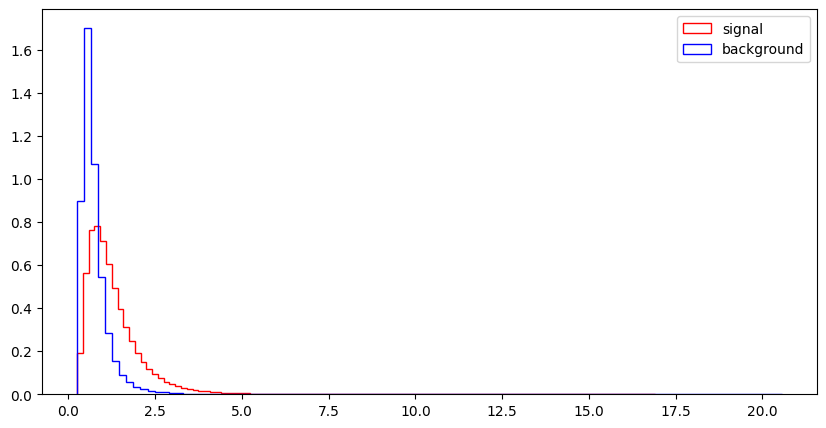

l_1_eta


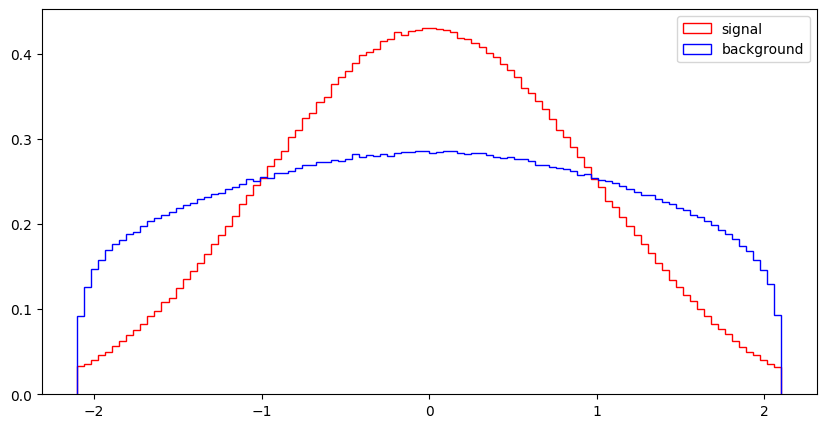

l_1_phi


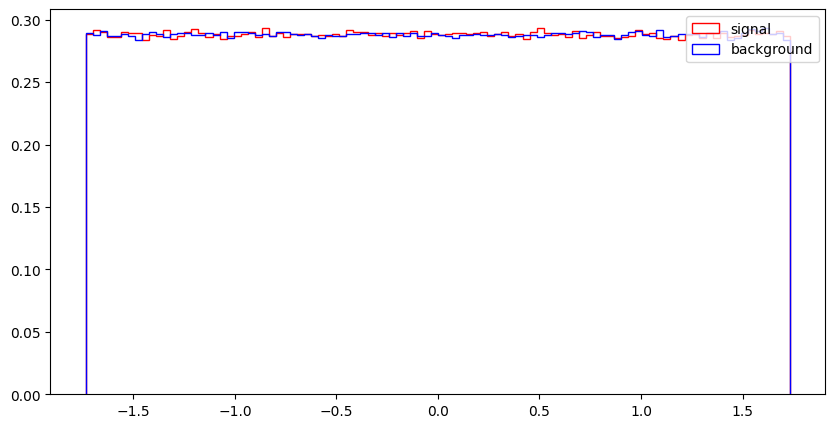

l_2_pT


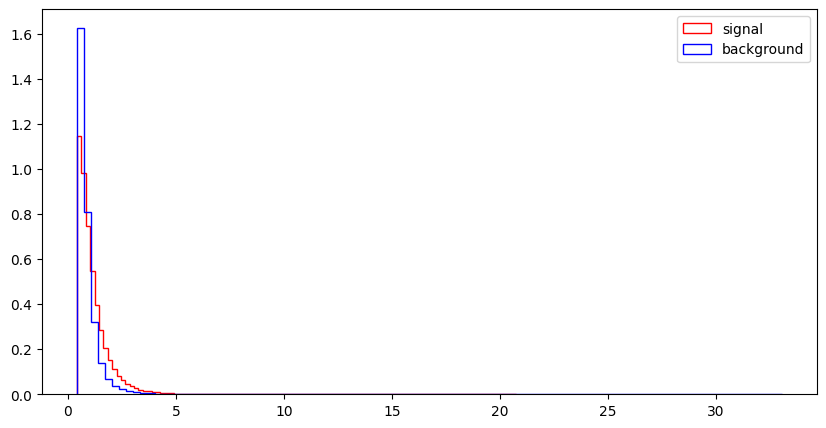

l_2_eta


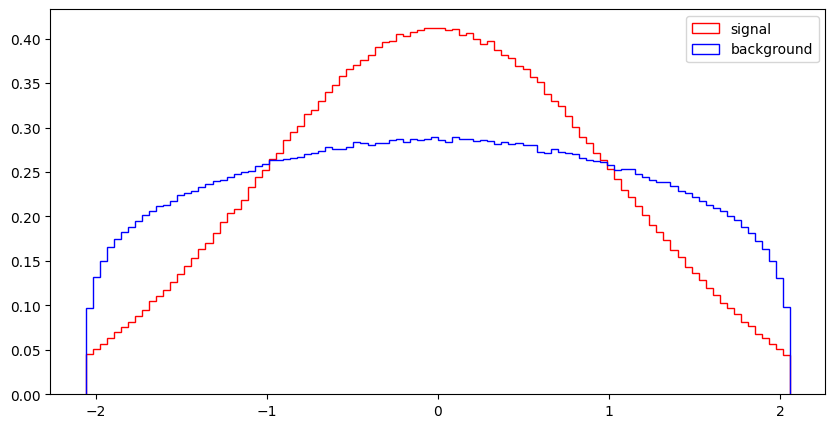

l_2_phi


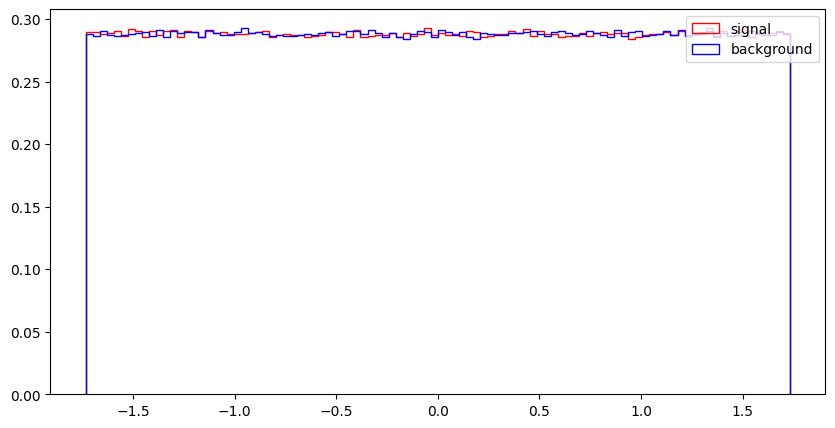

MET


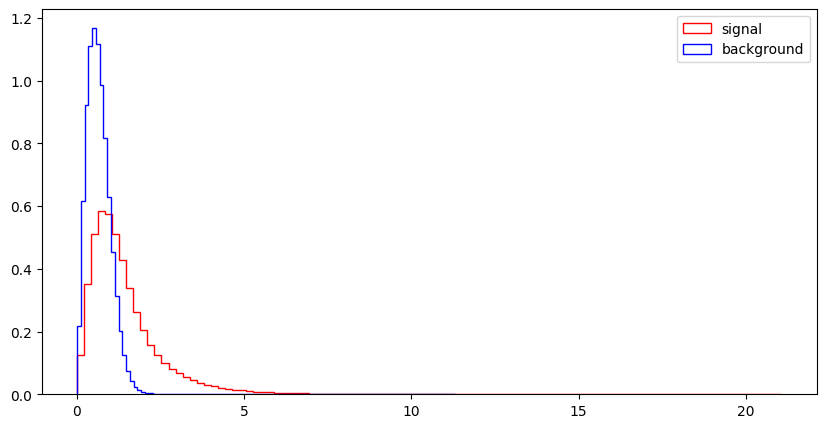

MET_phi


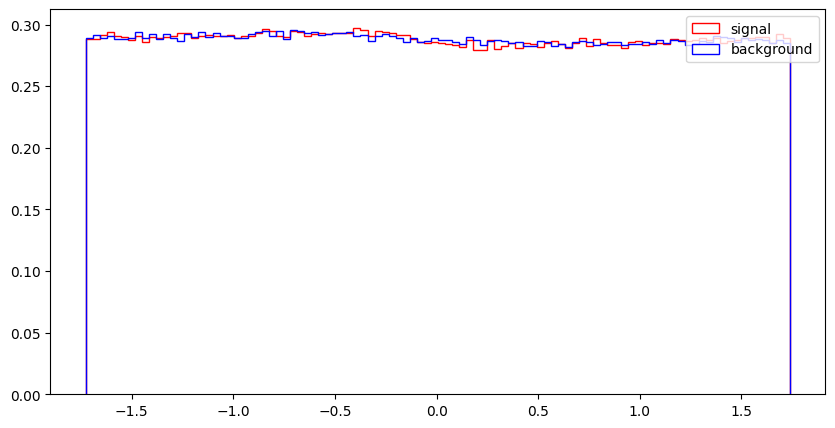

MET_rel


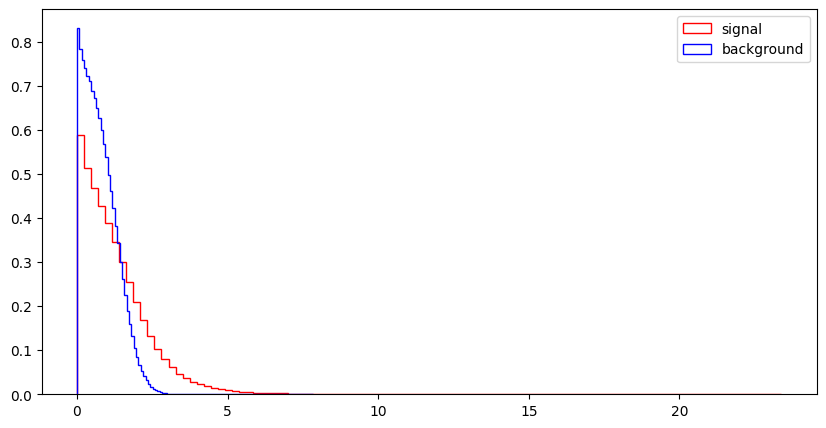

axial_MET


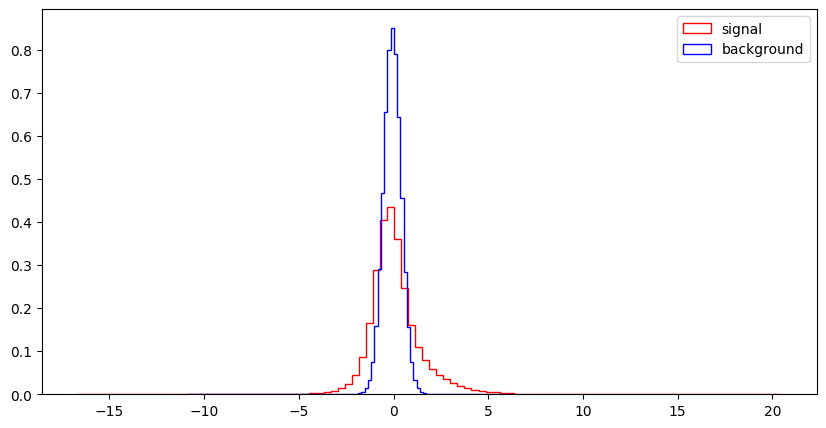

M_R


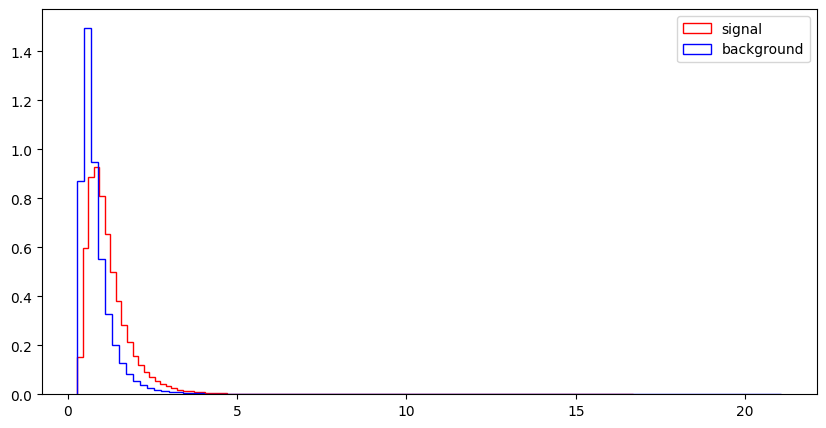

M_TR_2


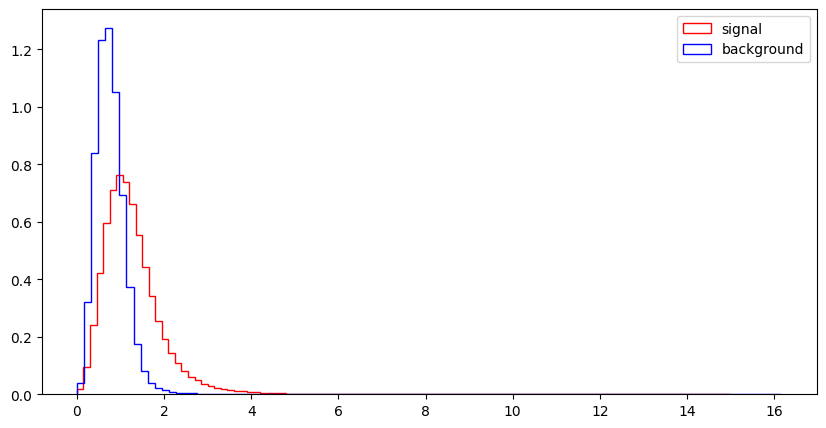

R


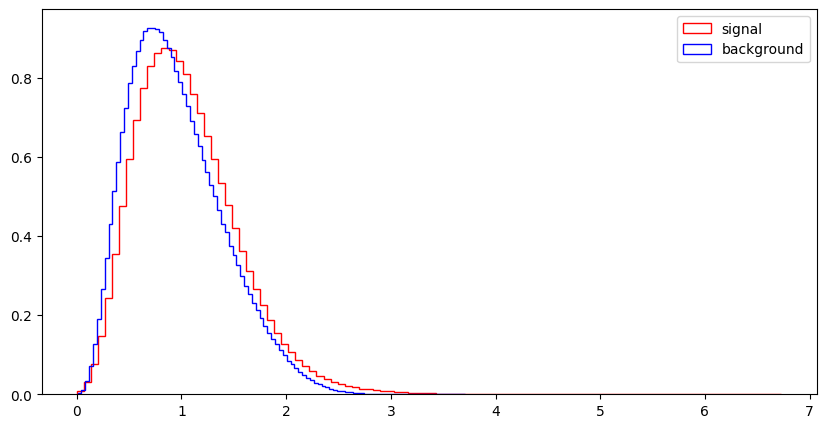

MT2


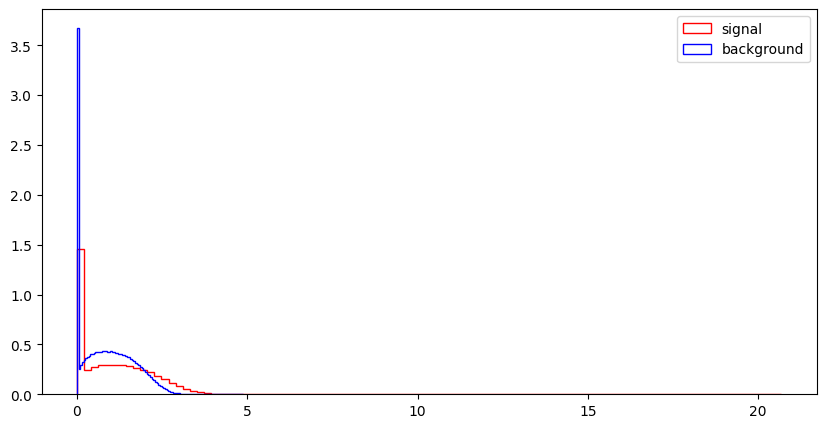

S_R


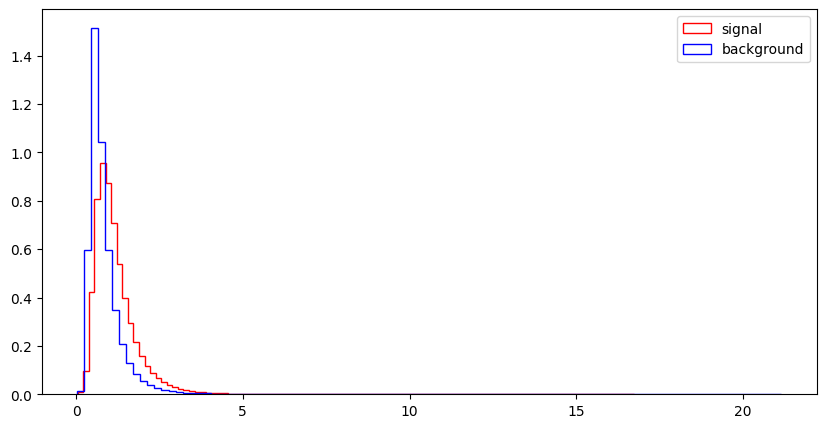

M_Delta_R


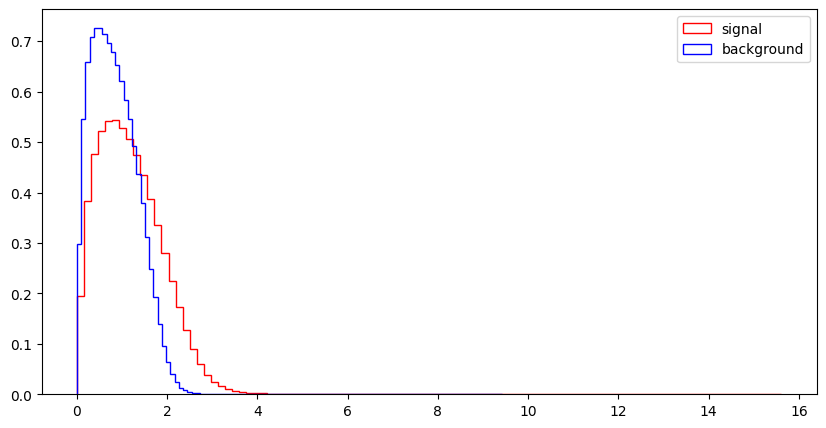

dPhi_r_b


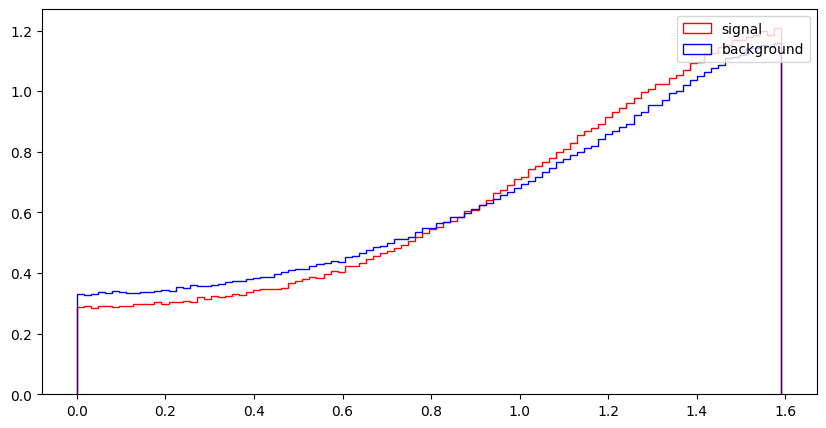

cos_theta_r1


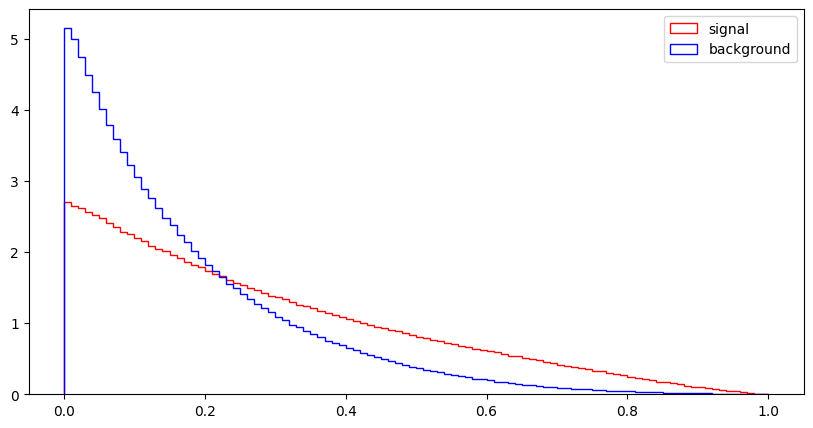

In [21]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

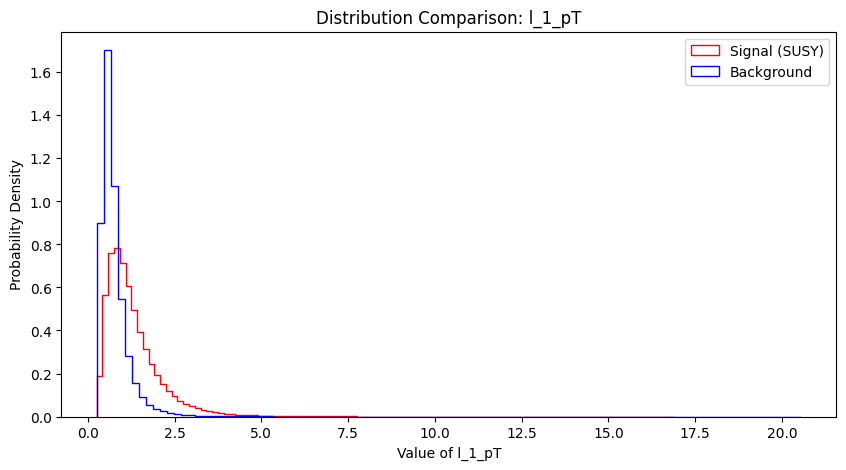

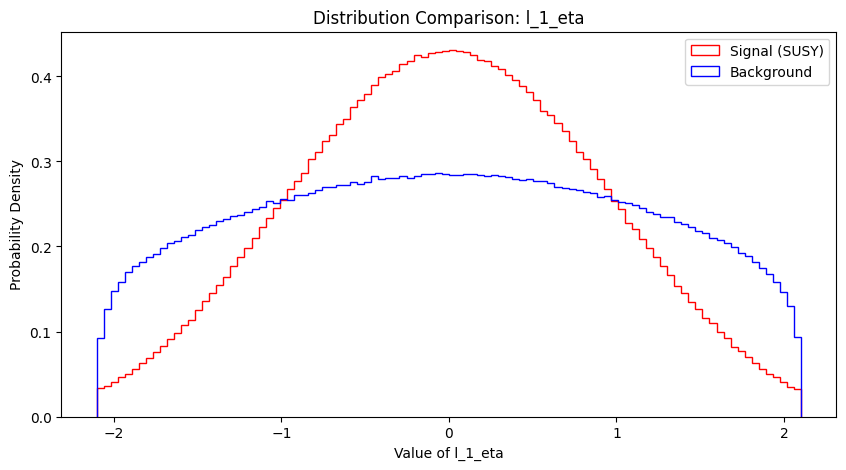

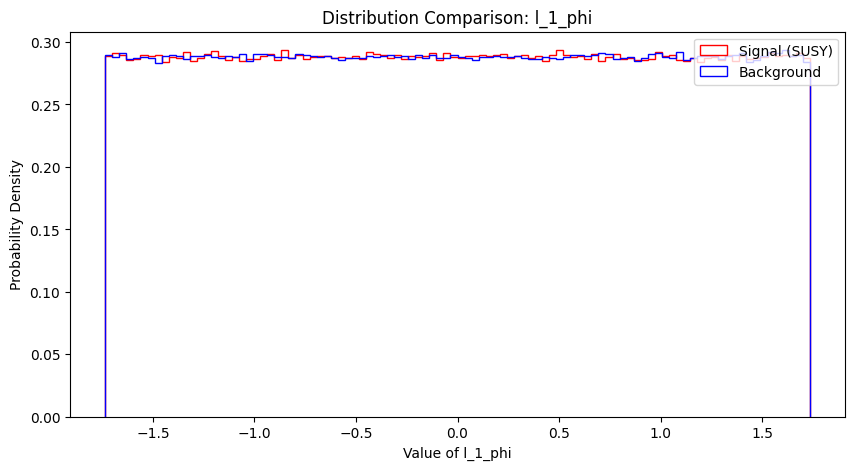

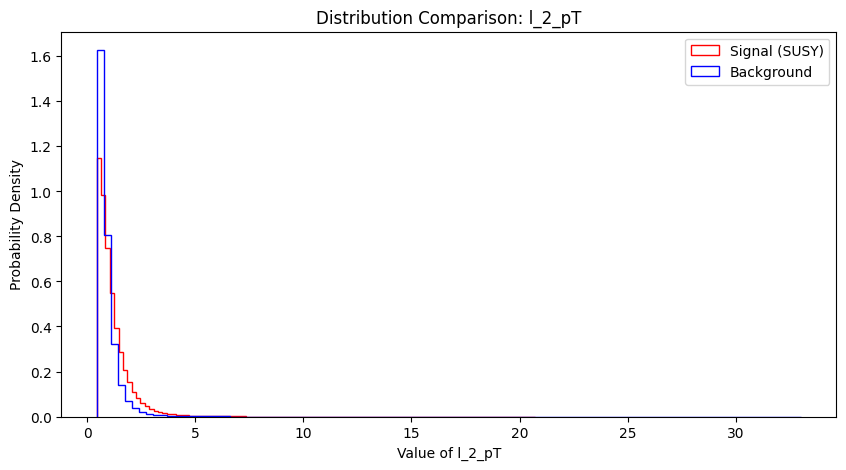

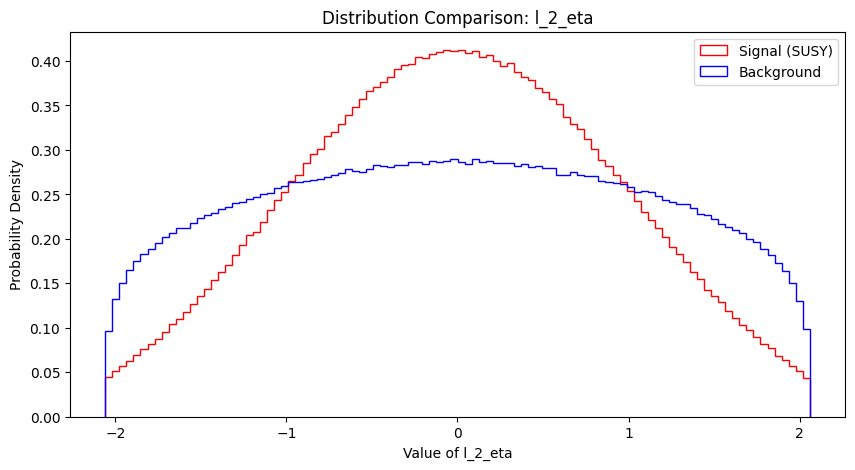

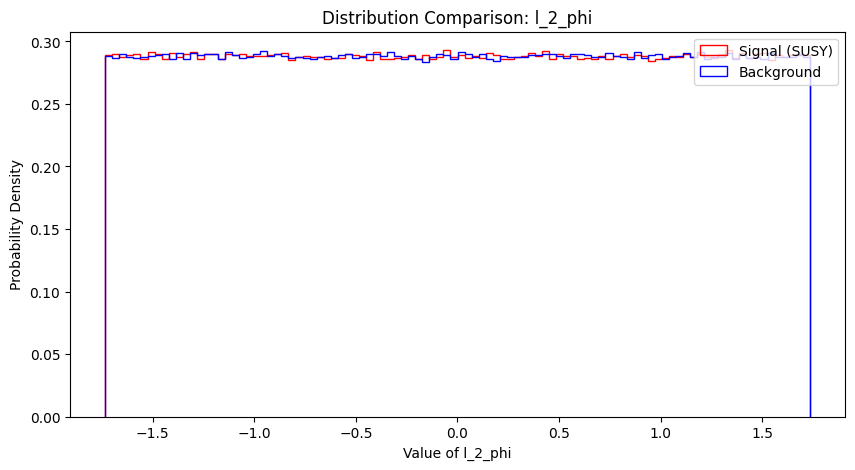

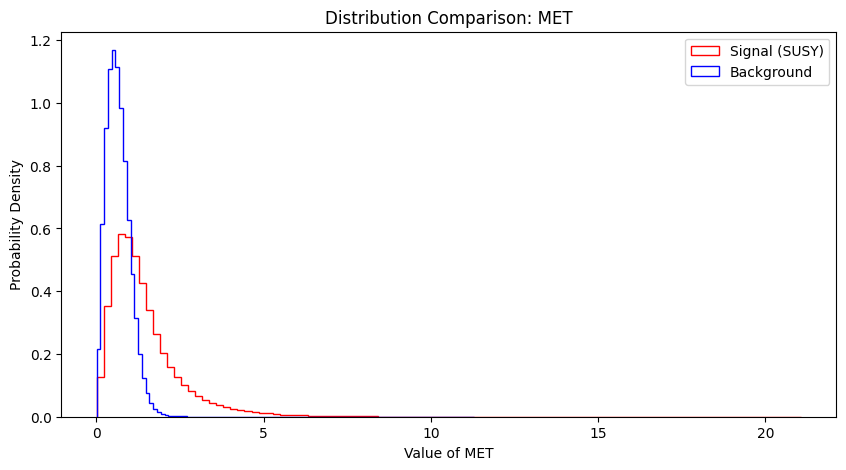

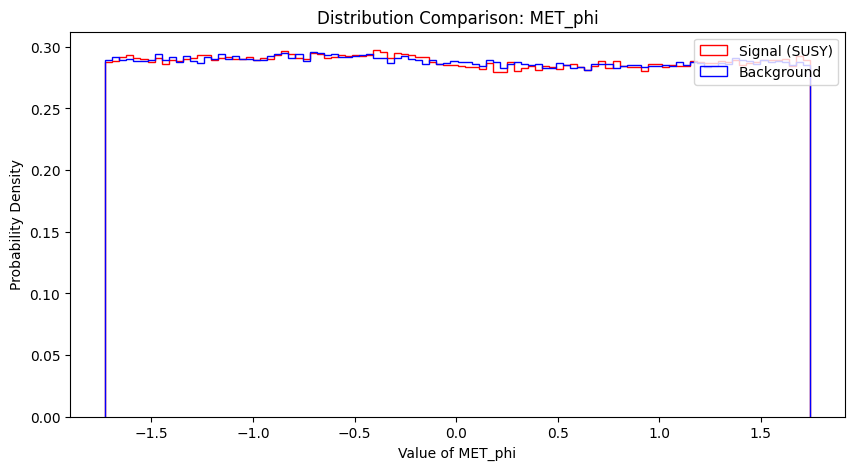

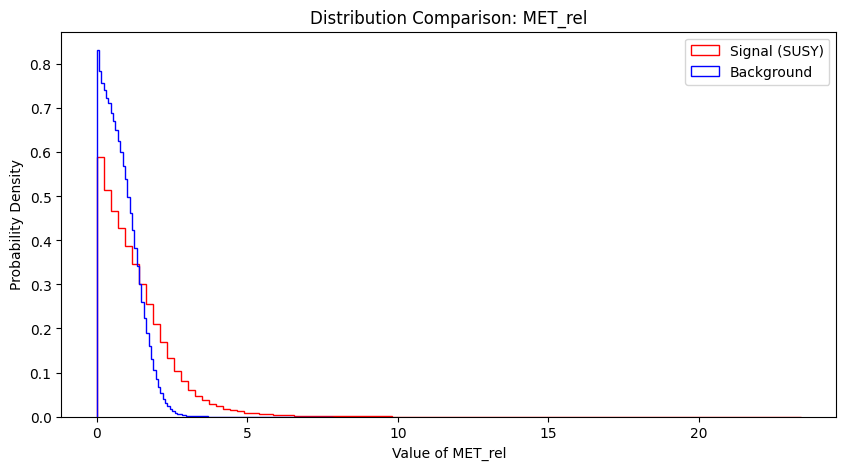

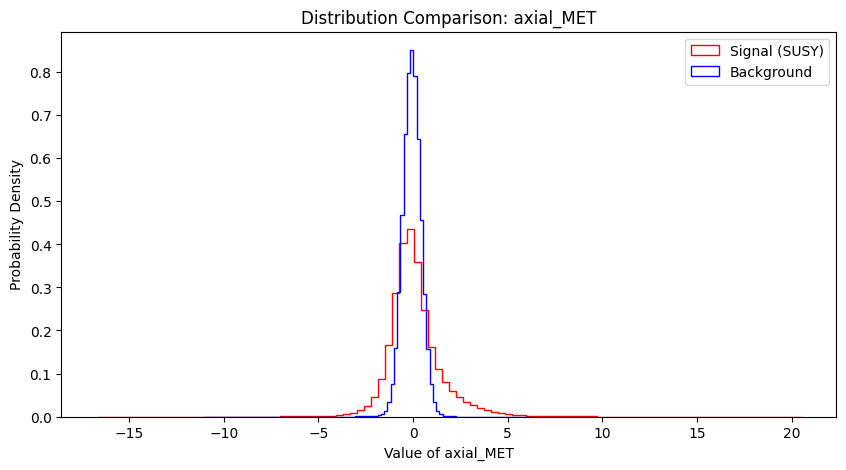

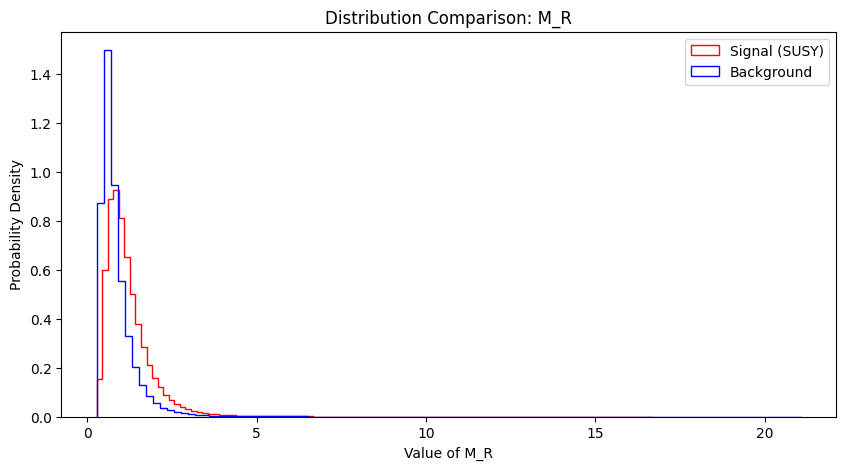

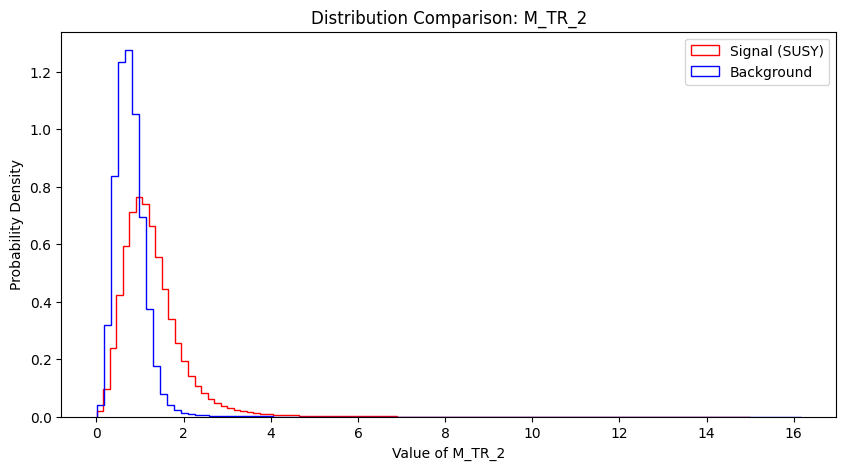

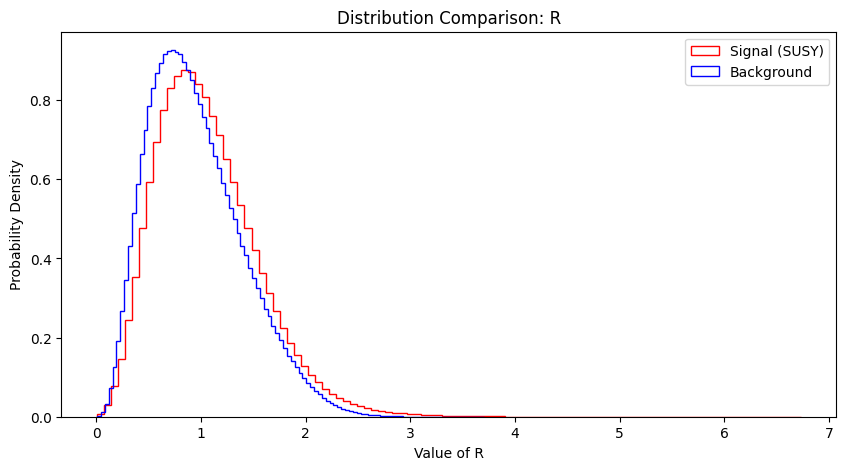

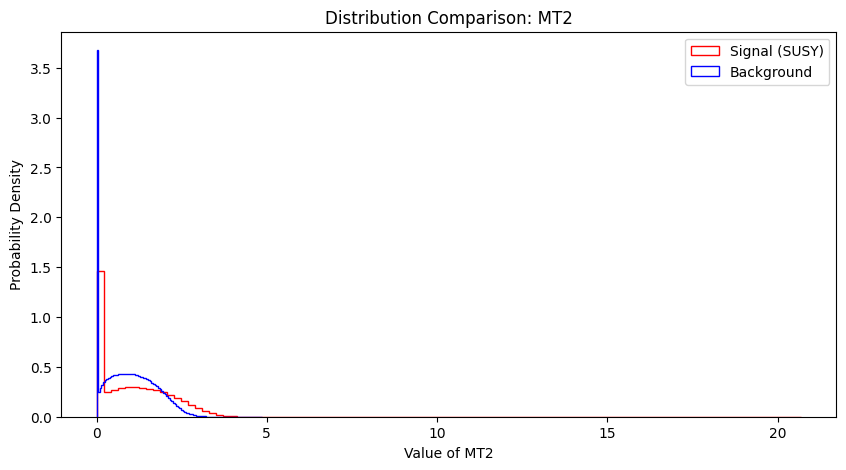

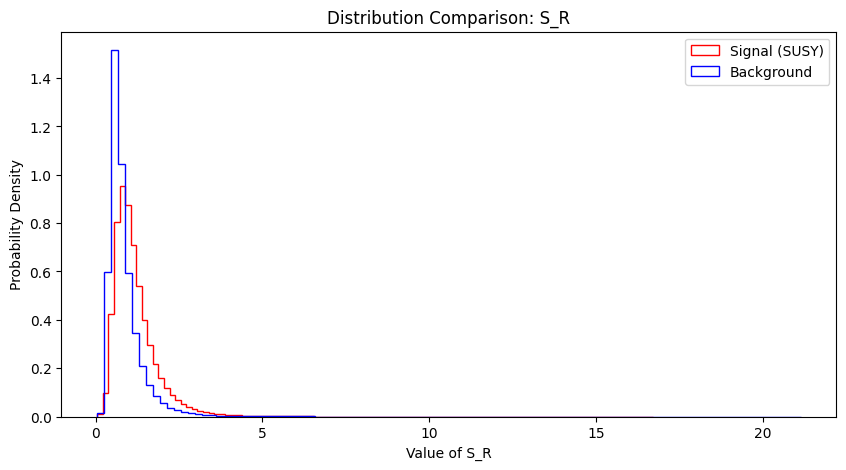

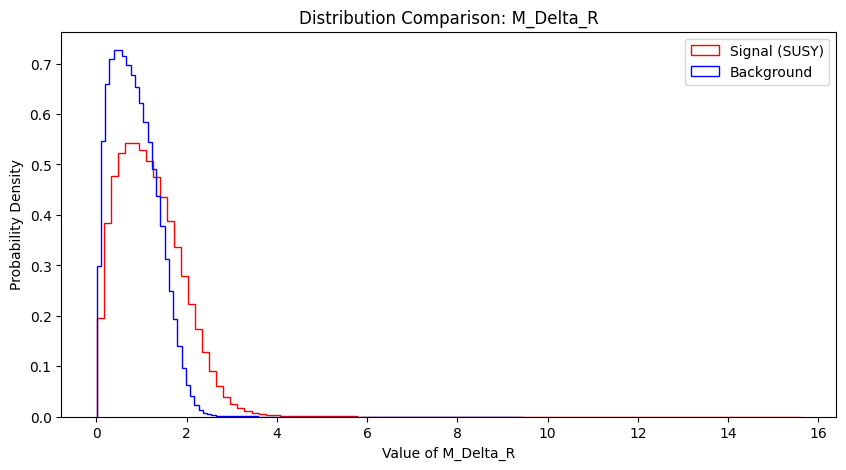

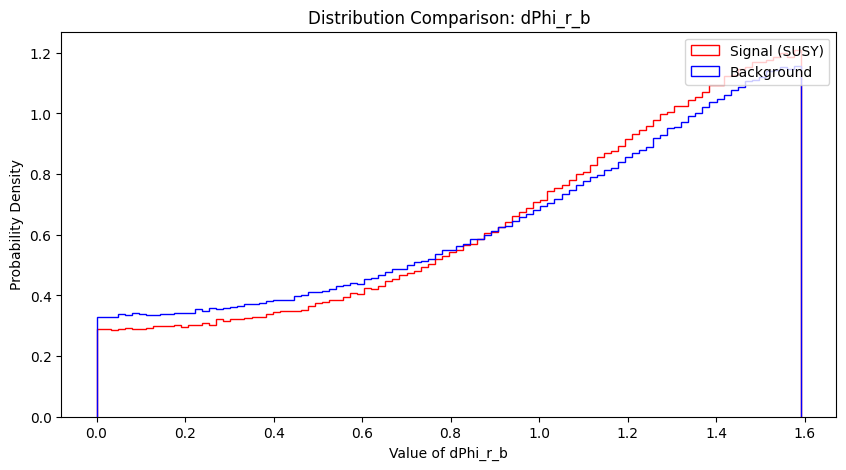

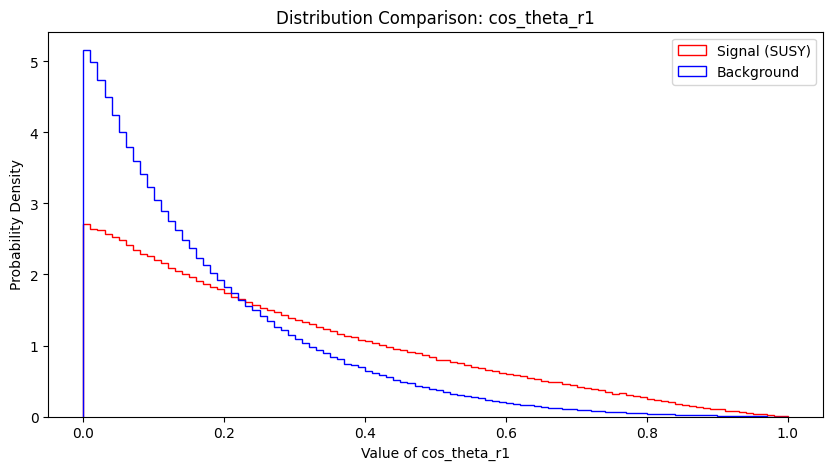

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# tells the notebook to render the plots directly below the code cell.
%matplotlib inline

# Separates the data based on the 'signal' column.
# The 'signal' column is 1.0 for a SUSY event and 0.0 for background.
df_sig = df[df.signal == 1]
df_bkg = df[df.signal == 0]

# Loops through every variable name except the first one
# VarNames[1:] starts from l_1_pT and goes to cos_theta_r1

for var in VarNames[1:]:
    
    # Creates a new figure for every variable so they don't overlap
    plt.figure(figsize=(10, 5))
    
    # np.array converts the pandas column to a numpy array for faster processing.
    # bins=100 divides the data range into 100 bars for detail.
    # histtype="step" draws a line instead of solid bars
    # density=True normalizes the area to 1. 
    # Since there are usually more background events than signal, they are normalized to compare the shape of distributions.
    plt.hist(np.array(df_sig[var]), bins=100, histtype="step", 
             color="red", label="Signal (SUSY)", density=True)
    
    # Plots the background
    plt.hist(np.array(df_bkg[var]), bins=100, histtype="step", 
             color="blue", label="Background", density=True)
    
    # Adds labels to make the plot more readable
    plt.title(f"Distribution Comparison: {var}")
    plt.xlabel(f"Value of {var}")
    plt.ylabel("Probability Density")
    
    # Adds a legend
    plt.legend(loc='upper right')
    
    # Final command to render the plot to the screen
    plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

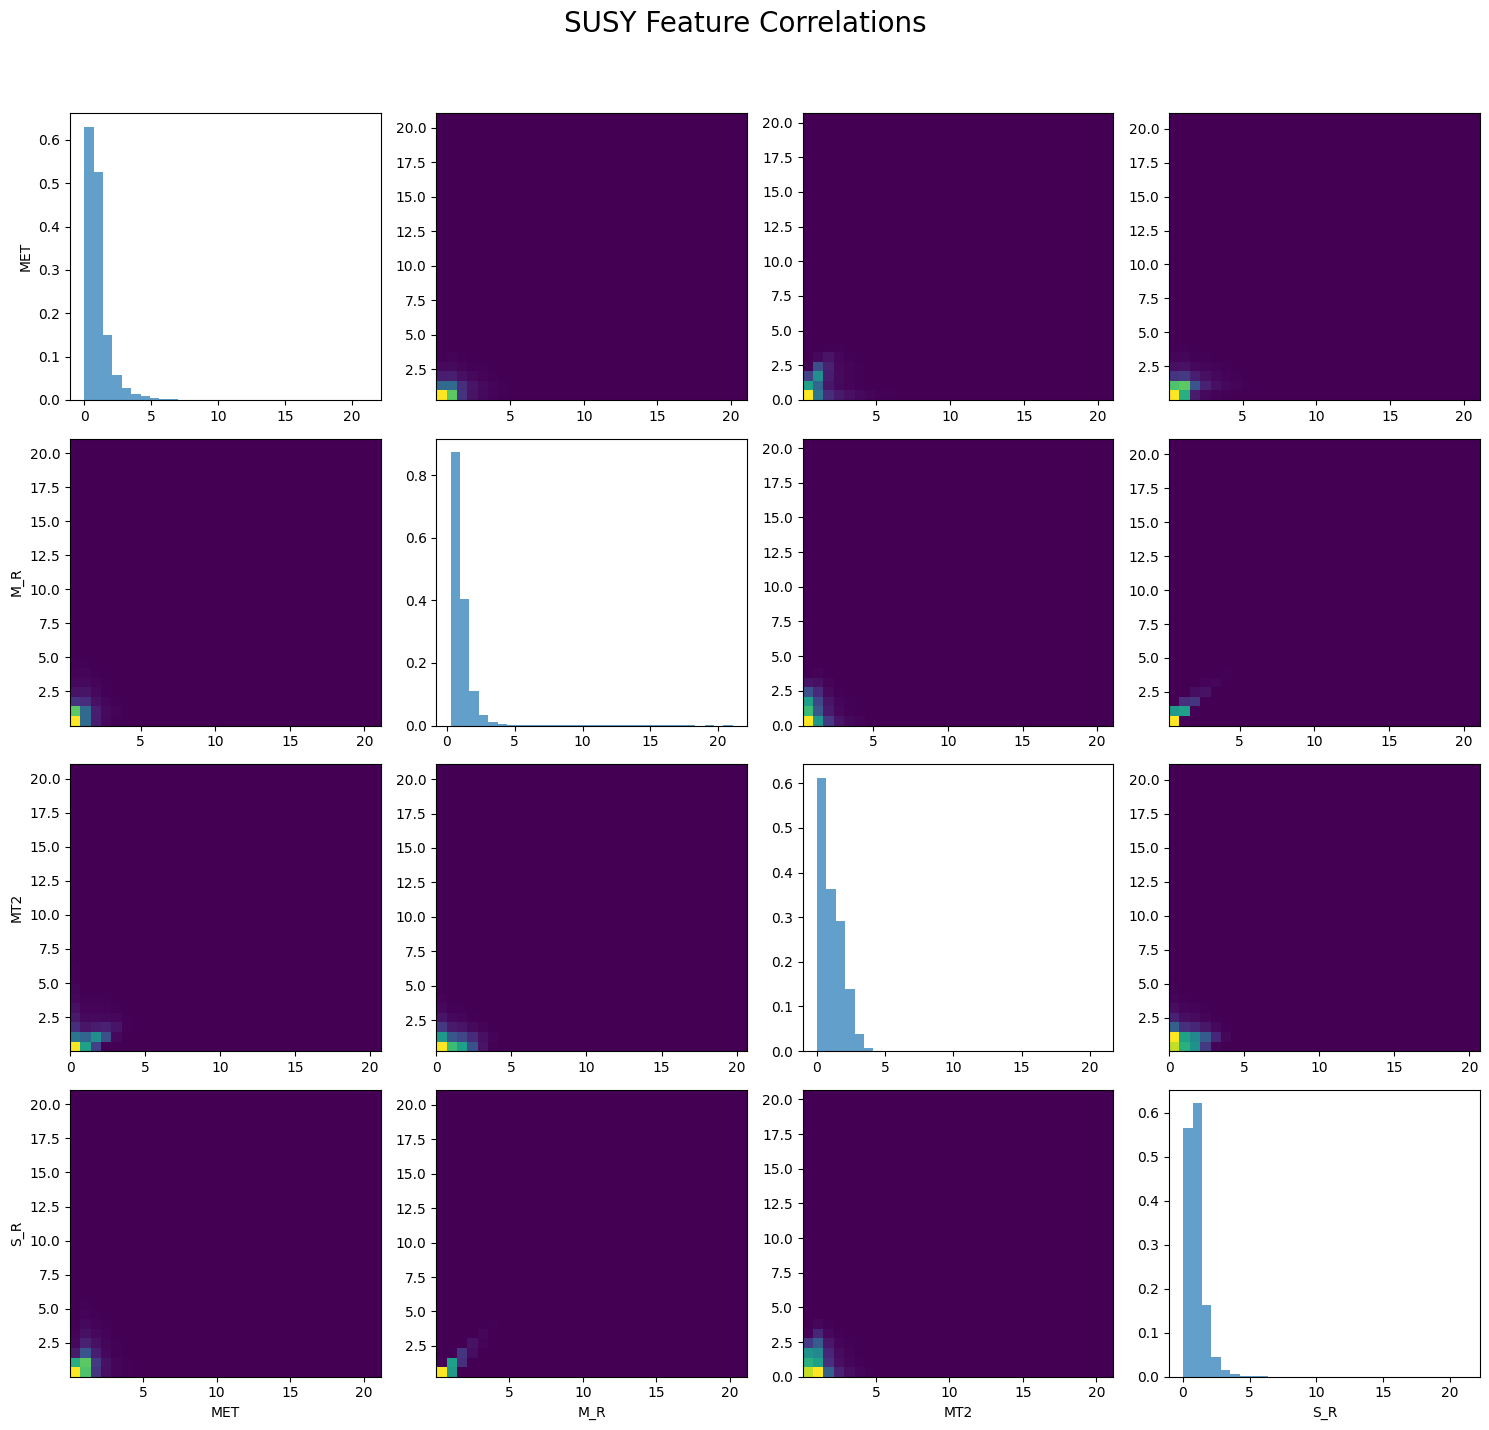

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import tabulate
from IPython.display import HTML, display

def fast_pair_plot(df, variables, title): # Creates a grid of plots to visualize correlations between multiple variables.
    n = len(variables)
    fig, axes = plt.subplots(n, n, figsize=(15, 15))
    
    for i, v1 in enumerate(variables): # Iterates through each row and column of the grid
        for j, v2 in enumerate(variables):
            if i == j: # Diagonal: The variable is being compared to itself. 
                axes[i, j].hist(df[v1], bins=30, density=True, alpha=0.7) 
            else: #Draws a 1D Histogram to show the distribution of that single variable.
                # Using Hist2d for speed
                # Scatter plots draw 500,000 dots which is slow while hist2d draws a faster grid.
                axes[i, j].hist2d(df[v1], df[v2], bins=30, cmap='viridis')
            
            if i == n - 1: axes[i, j].set_xlabel(v2)
            if j == 0: axes[i, j].set_ylabel(v1)
            
    plt.suptitle(title, fontsize=20)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for the title and prevent labels from overlapping
    plt.show()

features_to_plot = ["MET", "M_R", "MT2", "S_R"] # Selects a subset of features to plot
fast_pair_plot(df, features_to_plot, "SUSY Feature Correlations")

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [24]:
from IPython.display import HTML, display # Check if variables are redundant. High correlation (>0.8) means they provide similar information.
import tabulate

def display_corr_table(df, vars, title):
    corr = df[vars].corr()
    table_data = [[vars[i]] + list(row) for i, row in enumerate(corr.values)]
    headers = [""] + vars
    print(f"\n{title}")
    # This displays the HTML table
    display(HTML(tabulate.tabulate(table_data, headers=headers, tablefmt='html', floatfmt=".2f")))

# 
display_corr_table(df, FeatureNames, "High-Level Feature Correlations")


High-Level Feature Correlations


,M_R,cos_theta_r1,M_TR_2,S_R,axial_MET,MET_rel,R,dPhi_r_b,MT2,M_Delta_R
M_R,1.00,-0.11,0.58,0.98,0.02,0.08,-0.38,-0.11,-0.07,0.19
cos_theta_r1,-0.11,1.00,0.45,-0.08,-0.27,0.32,0.63,0.11,0.26,0.32
M_TR_2,0.58,0.45,1.00,0.64,-0.32,0.58,0.38,0.23,0.38,0.67
S_R,0.98,-0.08,0.64,1.00,-0.07,0.15,-0.29,-0.01,-0.02,0.25
axial_MET,0.02,-0.27,-0.32,-0.07,1.00,-0.14,-0.39,-0.06,-0.53,-0.37
MET_rel,0.08,0.32,0.58,0.15,-0.14,1.00,0.60,0.38,0.54,0.75
R,-0.38,0.63,0.38,-0.29,-0.39,0.60,1.00,0.42,0.57,0.56
dPhi_r_b,-0.11,0.11,0.23,-0.01,-0.06,0.38,0.42,1.00,0.06,0.16
MT2,-0.07,0.26,0.38,-0.02,-0.53,0.54,0.57,0.06,1.00,0.81
M_Delta_R,0.19,0.32,0.67,0.25,-0.37,0.75,0.56,0.16,0.81,1.00


Hint: Example code for embedding a `tabulate` table into a notebook:

In [25]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

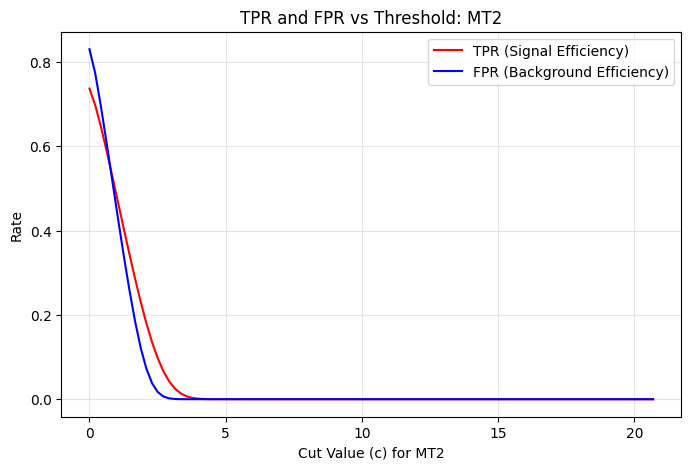

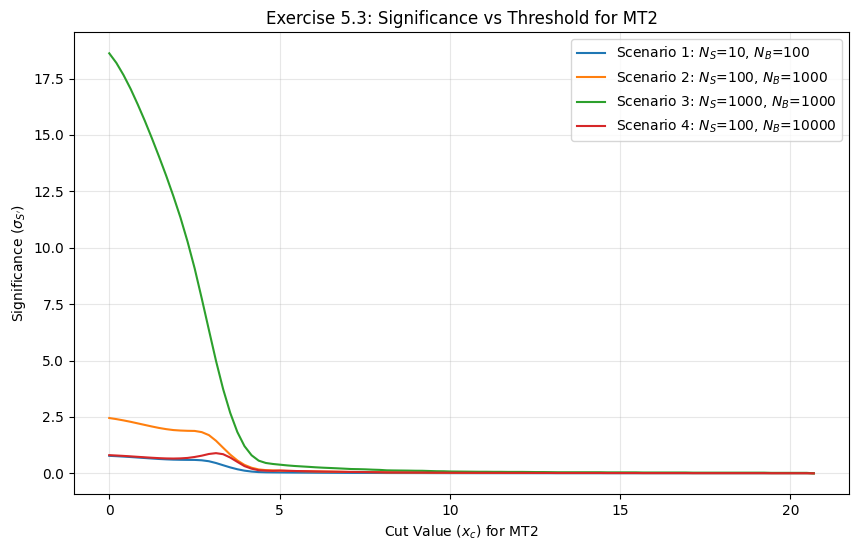

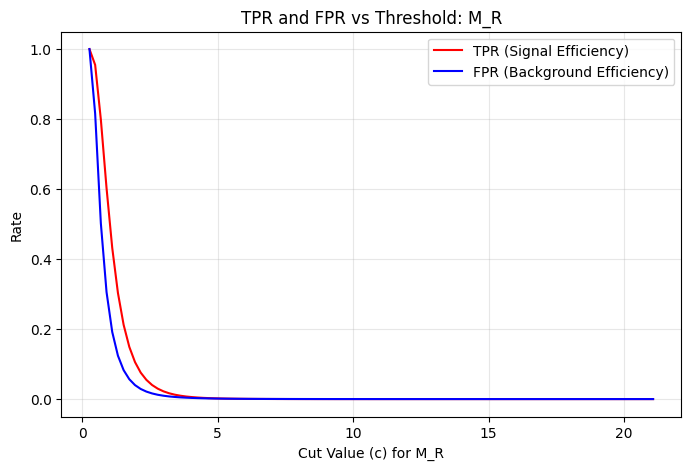

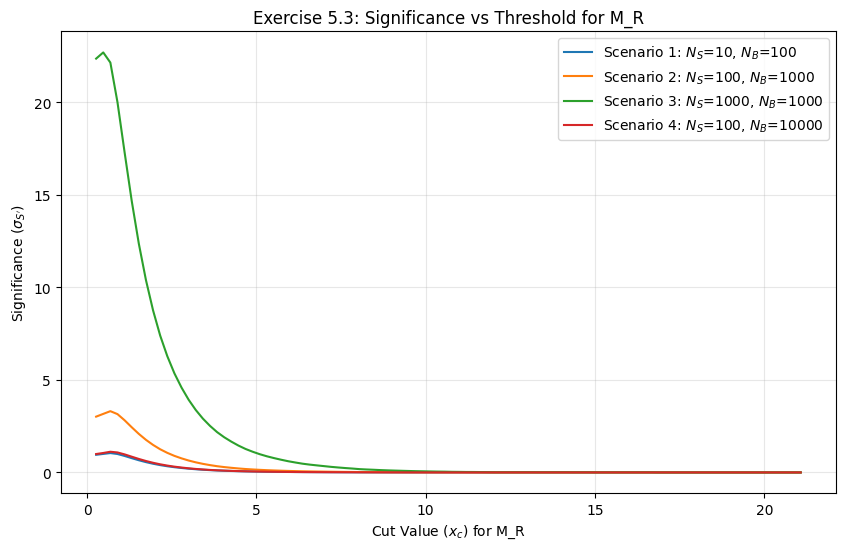

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def calculate_tpr_fpr(df, var, bins=100):
    # Determine the direction of the cut automatically
    sig_mean = df[df.signal == 1][var].mean()
    bkg_mean = df[df.signal == 0][var].mean() # Compares avg value of signal and background, if signal is higher then a greater than cut is needed, vice versa if lower.
    
    thresholds = np.linspace(df[var].min(), df[var].max(), bins) # Generate 100 possible cut values between the min and max of the variable
    tpr_list = []
    fpr_list = []
    
    # Pre-filter classes for speed 
    sig_data = df[df.signal == 1][var].values 
    bkg_data = df[df.signal == 0][var].values 
    n_sig = len(sig_data)
    n_bkg = len(bkg_data)
    
    for c in thresholds:
        if sig_mean > bkg_mean:
            # Signal is higher: select events > c
            tp = np.sum(sig_data > c)
            fp = np.sum(bkg_data > c)
        else:
            # Signal is lower: select events < c
            tp = np.sum(sig_data < c)
            fp = np.sum(bkg_data < c)  # tp = True Positives (Signal events that pass the cut) fp = False Positives (Background events that pass the cut)
        
        tpr_list.append(tp / n_sig if n_sig > 0 else 0)
        fpr_list.append(fp / n_bkg if n_bkg > 0 else 0)
    
    return thresholds, np.array(tpr_list), np.array(fpr_list)


def plot_tpr_fpr(df, var): # Plots how much signal vs background we keep as we change the cut.
    thresholds, tpr, fpr = calculate_tpr_fpr(df, var)
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, tpr, color='red', label='TPR (Signal Efficiency)')
    plt.plot(thresholds, fpr, color='blue', label='FPR (Background Efficiency)')
    plt.xlabel(f"Cut Value (c) for {var}")
    plt.ylabel("Rate")
    plt.title(f"TPR and FPR vs Threshold: {var}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_significance_for_scenarios(df, var, scenarios):
    thresholds, tpr, fpr = calculate_tpr_fpr(df, var)
    plt.figure(figsize=(10, 6))
    
    for n_s, n_b, name in scenarios:
        # N'_S,B = epsilon_S,B(xc) * N_S,B
        s_prime = n_s * tpr
        b_prime = n_b * fpr
        
        # Calculate statistical significance
        # 1e-10 prevents 'division by zero' errors if no events pass
        significance = s_prime / np.sqrt(s_prime + b_prime + 1e-10)
        
        plt.plot(thresholds, significance, label=f"{name}: $N_S$={n_s}, $N_B$={n_b}")
    
    plt.xlabel(f"Cut Value ($x_c$) for {var}")
    plt.ylabel(r"Significance ($\sigma_{S'}$)") # Added 'r' before the string to prevent the SyntaxWarning for \s
    plt.title(f"Exercise 5.3: Significance vs Threshold for {var}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
scenarios = [
    (10, 100, "Scenario 1"),      
    (100, 1000, "Scenario 2"),
    (1000, 1000, "Scenario 3"),
    (100, 10000, "Scenario 4")
]


for var in ['MT2', 'M_R']:
    plot_tpr_fpr(df, var)
    plot_significance_for_scenarios(df, var, scenarios)

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [34]:
def cut_flow_analysis(df, cuts, s_exp, b_exp):
    
    # Performs cut flow analysis for given selection cuts, cuts: list of (variable, cut_value, direction) where direction is '>' or '<'
    
    results = []
    
    # Start with all events, creates copy of dataset
    current_df = df.copy()
    
    for i, (var, cut_val, direction) in enumerate(cuts):
        # Apply cut
        if direction == '>':
            selected = current_df[current_df[var] > cut_val]
        else:
            selected = current_df[current_df[var] < cut_val]
        
        # Calculate metrics, initial totals for efficiency denominators
        n_sig_selected = len(selected[selected.signal == 1])
        n_bkg_selected = len(selected[selected.signal == 0])
        
        # Efficiency and purity
        eff_sig = n_sig_selected / len(df[df.signal == 1])
        eff_bkg = n_bkg_selected / len(df[df.signal == 0])
        purity = n_sig_selected / (n_sig_selected + n_bkg_selected) if (n_sig_selected + n_bkg_selected) > 0 else 0 # Efficiency is the fraction of the originaL signal/background that survived all cuts so far.
        # Purity is the fraction of signal in the current selected sample: S / (S + B)
        
        # Expected counts
        s_expected = s_exp * eff_sig
        b_expected = b_exp * eff_bkg
        significance = s_expected / np.sqrt(s_expected + b_expected) if (s_expected + b_expected) > 0 else 0
        
        results.append({
            'cut': f"{var} {direction} {cut_val:.3f}",
            'N_sig': n_sig_selected,
            'N_bkg': n_bkg_selected,
            'eff_sig': eff_sig,
            'eff_bkg': eff_bkg,
            'purity': purity,
            'S_exp': s_expected,
            'B_exp': b_expected,
            'significance': significance
        })
        
        current_df = selected
    
    # Create table, and stores results
    table_data = []
    for r in results:
        table_data.append([
            r['cut'],
            f"{r['N_sig']:.0f}",
            f"{r['N_bkg']:.0f}",
            f"{r['eff_sig']:.3f}",
            f"{r['eff_bkg']:.3f}",
            f"{r['purity']:.3f}",
            f"{r['S_exp']:.1f}",
            f"{r['B_exp']:.1f}",
            f"{r['significance']:.2f}"
        ])
    
    headers = ['Cut', 'N_sig', 'N_bkg', 'ε_sig', 'ε_bkg', 'Purity', 'S_exp', 'B_exp', 'Significance']
    display(HTML(tabulate.tabulate(table_data, headers=headers, tablefmt='html', floatfmt=".3f")))
    
    return results

# Example cut flow for Scenario 2 (S=100, B=1000)
print("\n" + "="*80)
print("Cut Flow Analysis - Scenario 2 (S=100, B=1000)")
print("="*80)

cuts = [
    ('MT2', 1.5, '>'),
    ('M_R', 1.0, '>'),
    ('MET_rel', 1.5, '>')
]

cut_flow_analysis(df, cuts, s_exp=100, b_exp=1000)


Cut Flow Analysis - Scenario 2 (S=100, B=1000)


Cut,N_sig,N_bkg,ε_sig,ε_bkg,Purity,S_exp,B_exp,Significance
MT2 > 1.500,765895,668326,0.335,0.246,0.534,33.500,246.400,2.000
M_R > 1.000,356269,137850,0.156,0.051,0.721,15.600,50.800,1.910
MET_rel > 1.500,227999,52108,0.100,0.019,0.814,10.000,19.200,1.840


[{'cut': 'MT2 > 1.500',
  'N_sig': 765895,
  'N_bkg': 668326,
  'eff_sig': 0.3347696307456814,
  'eff_bkg': 0.24641717176596037,
  'purity': 0.5340146323335107,
  'S_exp': 33.47696307456814,
  'B_exp': 246.41717176596038,
  'significance': np.float64(2.0010095174799454)},
 {'cut': 'M_R > 1.000',
  'N_sig': 356269,
  'N_bkg': 137850,
  'eff_sig': 0.15572375009124378,
  'eff_bkg': 0.05082640377291567,
  'purity': 0.7210186210204425,
  'S_exp': 15.572375009124379,
  'B_exp': 50.82640377291567,
  'significance': np.float64(1.9110621357091542)},
 {'cut': 'MET_rel > 1.500',
  'N_sig': 227999,
  'N_bkg': 52108,
  'eff_sig': 0.09965744787521084,
  'eff_bkg': 0.019212638721792453,
  'purity': 0.8139710896193241,
  'S_exp': 9.965744787521084,
  'B_exp': 19.21263872179245,
  'significance': np.float64(1.8449268316092837)}]

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



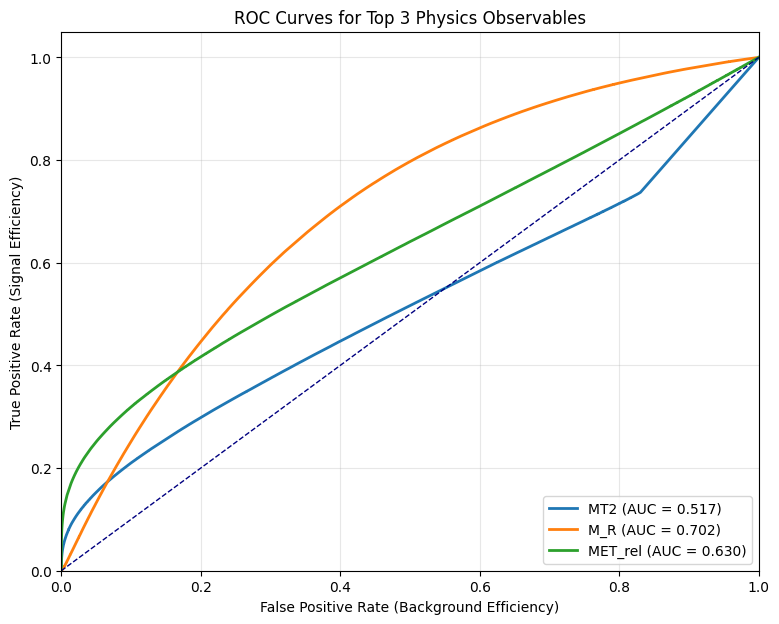

In [35]:
from sklearn.metrics import roc_curve, auc
#Excercises 7.1/7.2
def plot_roc_comparison(df, variables, title="ROC Curve Comparison"):
    
   # Function to overlay ROC curves for multiple variables and report AUC.
    
    plt.figure(figsize=(9, 7))
    
    for var in variables:
        # Generate the False Positive Rate and True Positive Rate
        # labels are in df['signal'], predictions are the variable values
        fpr, tpr, _ = roc_curve(df['signal'], df[var])
        
        # Calculate Area Under Curve
        roc_auc = auc(fpr, tpr)
        
        # If AUC < 0.5, the variable is inversely correlated (cuts would be x < c)
        # Flips it to keep the curve above the diagonal
        if roc_auc < 0.5:
            fpr, tpr, _ = roc_curve(df['signal'], -df[var])
            roc_auc = auc(fpr, tpr)
            
        plt.plot(fpr, tpr, lw=2, label=f'{var} (AUC = {roc_auc:.3f})')
    
    # Plot the 'Random Guess' diagonal line
    plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (Background Efficiency)')
    plt.ylabel('True Positive Rate (Signal Efficiency)')
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()


top_3 = ['MT2', 'M_R', 'MET_rel']
plot_roc_comparison(df, top_3, "ROC Curves for Top 3 Physics Observables")

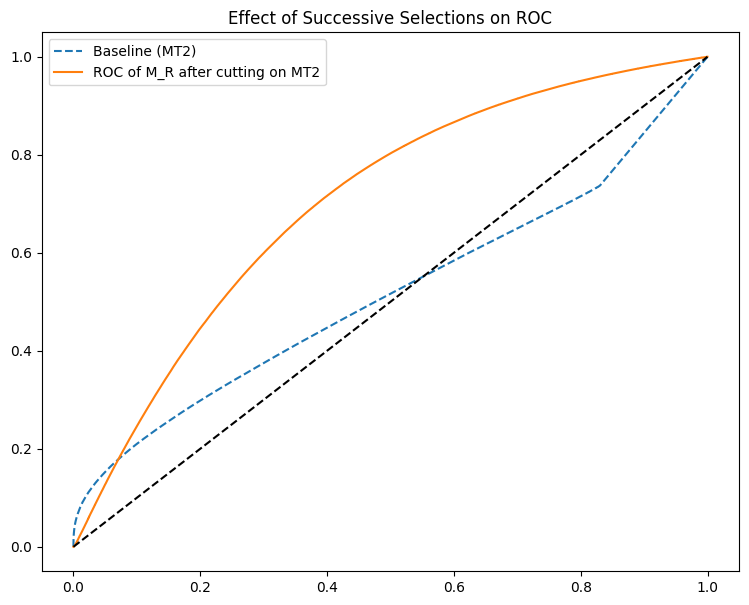

In [29]:
def plot_successive_roc(df, cuts):
#7.3
    current_df = df.copy()
    plt.figure(figsize=(9, 7))
    
    # Plot the baseline (no cuts) for the primary variable
    primary_var = cuts[0][0]
    fpr, tpr, _ = roc_curve(current_df['signal'], current_df[primary_var])
    plt.plot(fpr, tpr, label=f'Baseline ({primary_var})', linestyle='--')
    
    for i, (var, val, direction) in enumerate(cuts):
        # Apply the cut
        if direction == '>':
            current_df = current_df[current_df[var] > val]
        else:
            current_df = current_df[current_df[var] < val]
            
        # Plot the ROC of the NEXT variable in the chain on the REMAINING data
        if i + 1 < len(cuts):
            next_var = cuts[i+1][0]
            fpr, tpr, _ = roc_curve(current_df['signal'], current_df[next_var])
            plt.plot(fpr, tpr, label=f'ROC of {next_var} after cutting on {var}')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title("Effect of Successive Selections on ROC")
    plt.legend()
    plt.show()

# Example usage
successive_cuts = [('MT2', 1.0, '>'), ('M_R', 0.8, '>')]
plot_successive_roc(df, successive_cuts)

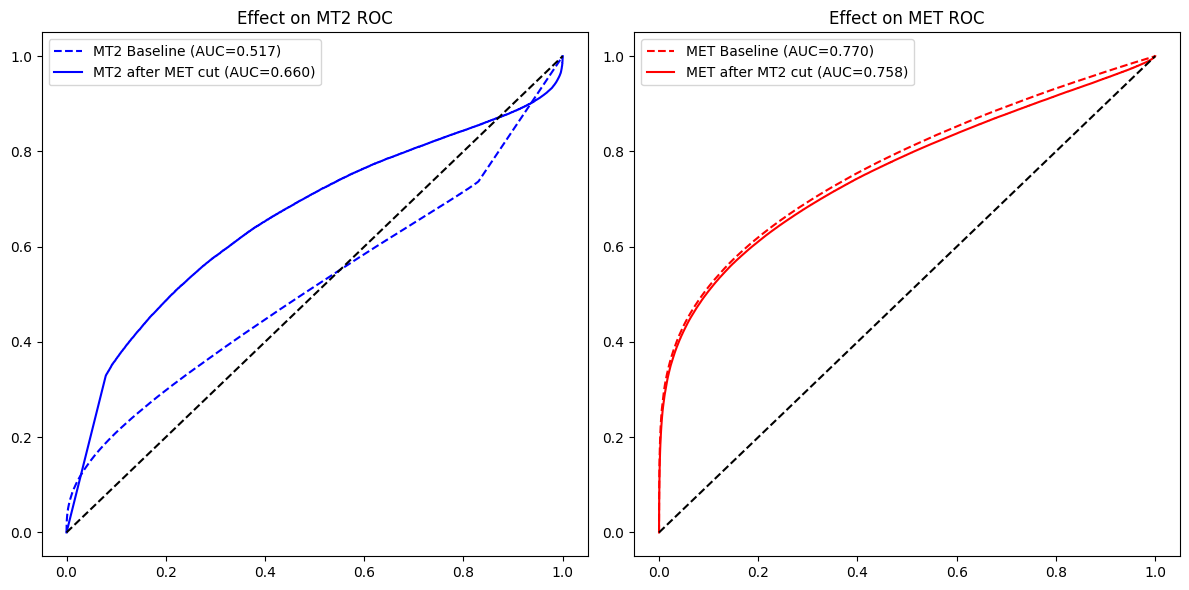

In [30]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

def get_roc_info(data, var):
    """Helper to get ROC and AUC using sklearn"""
    fpr, tpr, _ = roc_curve(data['signal'], data[var])
    roc_auc = auc(fpr, tpr)
    # Ensure AUC is > 0.5 (flip if the variable is inversely correlated)
    if roc_auc < 0.5:
        fpr, tpr, _ = roc_curve(data['signal'], -data[var])
        roc_auc = auc(fpr, tpr)
    return fpr, tpr, roc_auc

# Define two correlated variables for the demonstration
var1 = 'MT2'
var2 = 'MET'

# Case A: Baseline (No previous cuts) ---
fpr1_base, tpr1_base, auc1_base = get_roc_info(df, var1)
fpr2_base, tpr2_base, auc2_base = get_roc_info(df, var2)

# Case B: Path 1 (Cut on MET first, then check MT2 ROC) ---
df_after_met = df[df['MET'] > 1.5]
fpr1_after_met, tpr1_after_met, auc1_after_met = get_roc_info(df_after_met, var1)

# Case C: Path 2 (Cut on MT2 first, then check MET ROC) ---
df_after_mt2 = df[df['MT2'] > 1.5]
fpr2_after_mt2, tpr2_after_mt2, auc2_after_mt2 = get_roc_info(df_after_mt2, var2)

# Plotting the Comparison
plt.figure(figsize=(12, 6))

# Plot for MT2 performance change
plt.subplot(1, 2, 1)
plt.plot(fpr1_base, tpr1_base, 'b--', label=f'MT2 Baseline (AUC={auc1_base:.3f})')
plt.plot(fpr1_after_met, tpr1_after_met, 'b-', label=f'MT2 after MET cut (AUC={auc1_after_met:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Effect on MT2 ROC")
plt.legend()

# Plot for MET performance change
plt.subplot(1, 2, 2)
plt.plot(fpr2_base, tpr2_base, 'r--', label=f'MET Baseline (AUC={auc2_base:.3f})')
plt.plot(fpr2_after_mt2, tpr2_after_mt2, 'r-', label=f'MET after MT2 cut (AUC={auc2_after_mt2:.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Effect on MET ROC")
plt.legend()

plt.tight_layout()
plt.show()

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

In [36]:
import numpy as np

# Select the features to include (Raw and High-level)
features = RawNames + FeatureNames

# 1. Separate the data into Signal and Background
X_sig = df[df.signal == 1][features].values
X_bkg = df[df.signal == 0][features].values

# 2. Compute the mean vectors (m1 for signal, m2 for background)
m1 = np.mean(X_sig, axis=0)
m2 = np.mean(X_bkg, axis=0)

# 3. Compute Within-class Covariance Matrix (S_W)
# S_W is the sum of the covariance matrices of the two classes
S_W = np.cov(X_sig.T) + np.cov(X_bkg.T)

# 4. Compute Between-class Covariance Matrix (S_B)
# S_B = (m2 - m1)(m2 - m1)^T
diff = (m2 - m1).reshape(-1, 1)
S_B = diff @ diff.T

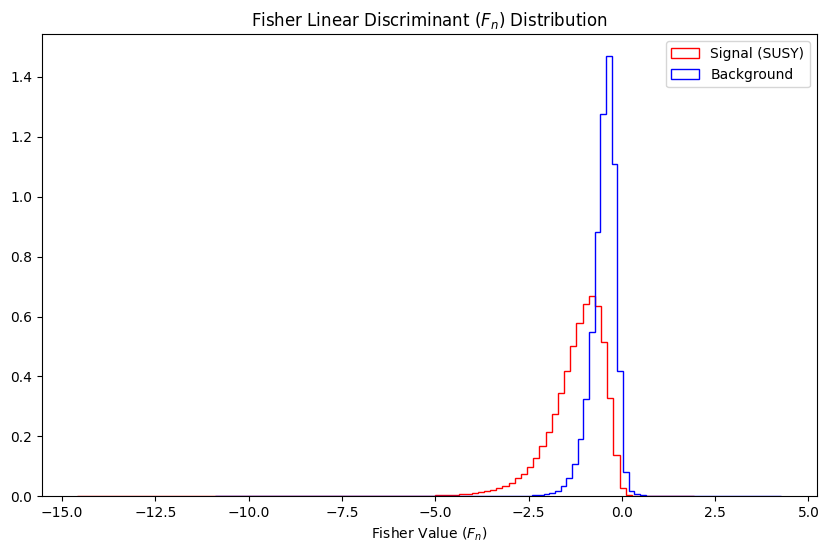

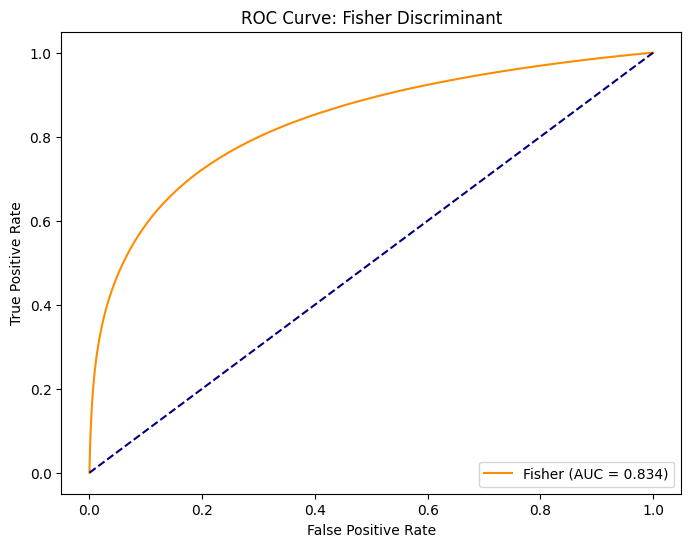

Max Significance for Scenario 4: 2.22 sigma


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc


# Raw kinematic features
RawNames = ["l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]

# High-level physics features 
FeatureNames = ["axial_MET", "MET_rel", "M_R", "cos_theta_r1", "MT2", 
                "dPhi_r_b", "M_TR_2", "R", "S_R", "M_Delta_R"]

# Combine them for the Fisher Discriminant
all_features = RawNames + FeatureNames

# Exercise 8.1: Compute Sw and Sb
# Separate signal and background
X_sig = df[df.signal == 1][all_features].values
X_bkg = df[df.signal == 0][all_features].values

# Compute means
m1 = np.mean(X_sig, axis=0) # Signal Mean
m2 = np.mean(X_bkg, axis=0) # Background Mean

# Compute Within-class Covariance (Sw)
# Sw = Cov(Signal) + Cov(Background)
S_W = np.cov(X_sig.T) + np.cov(X_bkg.T)

# Exercise 8.2: Compute w and Fn
# Compute weights: w = Sw^-1 * (m2 - m1)
# solve is used instead of inv for numerical stability
w = np.linalg.solve(S_W, (m2 - m1))

# Project data to get Fisher Discriminant values: Fn = X * w
df['Fisher_F'] = df[all_features].values @ w

# Plot histograms
plt.figure(figsize=(10, 6))
plt.hist(df[df.signal == 1]['Fisher_F'], bins=100, color='red', 
         histtype='step', label='Signal (SUSY)', density=True)
plt.hist(df[df.signal == 0]['Fisher_F'], bins=100, color='blue', 
         histtype='step', label='Background', density=True)
plt.title("Fisher Linear Discriminant ($F_n$) Distribution")
plt.xlabel("Fisher Value ($F_n$)")
plt.legend()
plt.show()

# Exercise 8.3:
fpr, tpr, _ = roc_curve(df['signal'], df['Fisher_F'])
roc_auc = auc(fpr, tpr)

# Correct if curve is flipped
if roc_auc < 0.5:
    fpr, tpr, _ = roc_curve(df['signal'], -df['Fisher_F'])
    roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'Fisher (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Fisher Discriminant')
plt.legend(loc="lower right")
plt.show()

# Exercise 8.4: Maximal Significance
# Uses function from Exercise 5 to find the peak significance
# Example for Scenario 4 (S=100, B=10,000)
thresholds, tpr_pts, fpr_pts = calculate_tpr_fpr(df, 'Fisher_F')
s_pass = 100 * tpr_pts
b_pass = 10000 * fpr_pts
significance = s_pass / np.sqrt(s_pass + b_pass + 1e-10)

print(f"Max Significance for Scenario 4: {np.max(significance):.2f} sigma")